# 06. Price prediction modeling

Unified classifier: one model outputs `P(filled)` for any `(ticker, monday, type, otm_pct)` query.

**Inputs** (25): 23 price features from `price_features.parquet` + `otm_pct` (continuous 0.01-0.05) + `type_cc` (binary 1 for CC, 0 for CSP).

**Target**: binary `filled = 1 if option gets assigned at Friday close else 0`. This is the direct decision-relevant outcome — does the contract I'm selling get exercised.

**Four models**:

- **RandomForest** (tabular): depth 10, 300 trees — baseline
- **XGBoost** (tabular, CUDA): depth 6, 400 trees, lr=0.05, hist method
- **LightGBM** (tabular): same hyperparameters, with L2 regularization
- **PyTorch LSTM** (sequences + static): 2-layer LSTM-64 on 30 days of raw log-returns + high/low range + log-volume + SPY log-returns, concatenated with `[otm_pct, type_cc]` static features, then MLP head

**Baseline to beat**: delta baseline = `|delta|` of an options chain contract with moneyness ≈ `otm_pct`. This is the market's implied probability of assignment, available for free from any options quote.

**Decision criterion**: best model = highest mean AUC across the 10 (type × OTM) test slices, subject to beating the delta baseline in the 4-5% OTM zone (where strategy actually operates).


In [1]:
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score

from config import HIGH_QUALITY_TICKERS


FEATURES_PATH = Path("output/07_price_prediction_feature_engineering/price_features.parquet")
LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
MODEL_OUT = Path("output/08_price_prediction_modeling/price_model.pkl")
PRED_OUT = Path("output/08_price_prediction_modeling/price_model_predictions.parquet")
OUT_DIR = Path("output/08_price_prediction_modeling")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
OTM_THRESHOLDS = [0.01, 0.02, 0.03, 0.04, 0.05]
SEQ_LEN = 30

ALL_FEATURES = [
    "ret_5d",
    "ret_20d",
    "ret_60d",
    "ret_5d_minus_20d",
    "ret_20d_minus_60d",
    "vol_20d",
    "vol_60d",
    "vol_ratio_20_60",
    "parkinson_vol_20d",
    "close_to_ma20",
    "close_to_ma50",
    "close_to_ma200",
    "ma20_to_ma50",
    "max_dd_60d",
    "dist_from_52w_high",
    "rsi_14",
    "zscore_20d",
    "bbands_pos",
    "volume_ratio_20d",
    "log_volume",
    "spy_ret_20d",
    "spy_vol_20d",
    "spy_close_to_ma50",
]
STATIC_INPUTS = ALL_FEATURES + ["otm_pct", "type_cc"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## Load features + labels, build augmented dataset

For each `(ticker, monday)` row in `price_features.parquet` we create 10 augmented rows: 5 OTM thresholds × 2 types. Each row has features + strike-offset + the realized `filled` label. This lets one unified model handle any strike query.

In [2]:
features = pd.read_parquet(FEATURES_PATH)
features["monday_date"] = pd.to_datetime(features["monday_date"])
labels = pd.read_parquet(LABELS_PATH)
labels["monday_date"] = pd.to_datetime(labels["monday_date"])

aug_rows = []
for r in features.itertuples():
    fv = {f: getattr(r, f) for f in ALL_FEATURES}
    base = {
        "ticker": r.ticker,
        "monday_date": r.monday_date,
        "monday_close": r.monday_close,
        "friday_close": r.friday_close,
        "forward_ret": r.forward_ret,
        **fv,
    }
    for pct in OTM_THRESHOLDS:
        for type_code, type_key in [(1, "CC"), (0, "CSP")]:
            filled = (
                int(r.forward_ret >= pct)
                if type_key == "CC"
                else int(r.forward_ret <= -pct)
            )
            aug_rows.append(
                {
                    **base,
                    "otm_pct": pct,
                    "type_cc": type_code,
                    "type": type_key,
                    "filled": filled,
                }
            )
aug = pd.DataFrame(aug_rows)
print(f"augmented: {len(aug):,} rows  ({len(features):,} (ticker,monday) x 10)")

augmented: 66,310 rows  (6,631 (ticker,monday) x 10)


## Delta baseline lookup

For each augmented row, find the strategy_labels contract with matching `(ticker, monday, type)` whose moneyness is closest to `otm_pct`. Use `|delta|` as `p_mkt_filled`. This is the free market signal we need to beat.

In [3]:
label_for_delta = labels[
    ["ticker", "monday_date", "type", "moneyness_actual", "delta"]
].copy()


def delta_for(ticker, monday, type_key, target_otm):
    sub = label_for_delta[
        (label_for_delta.ticker == ticker)
        & (label_for_delta.monday_date == monday)
        & (label_for_delta["type"] == type_key)
    ]
    if sub.empty:
        return None
    idx = (sub["moneyness_actual"] - target_otm).abs().idxmin()
    return float(sub.loc[idx, "delta"])


deltas = []
for r in aug.itertuples():
    d = delta_for(r.ticker, r.monday_date, r.type, r.otm_pct)
    deltas.append(d)
aug["delta_for_this_strike"] = deltas
aug["p_mkt_filled"] = aug["delta_for_this_strike"].abs()
print(f"NaN delta lookups: {aug['p_mkt_filled'].isna().sum():,} / {len(aug):,}")

NaN delta lookups: 2,100 / 66,310


## Temporal train/test split

80/20 on calendar time. Test = the most recent ~20% of Mondays. No shuffle — we never train on future data.

In [4]:
split_date = aug["monday_date"].quantile(0.8)
train = aug[aug["monday_date"] < split_date].copy()
test = aug[aug["monday_date"] >= split_date].copy()
print(f"split at {split_date.date()}: train={len(train):,}  test={len(test):,}")

X_train = train[STATIC_INPUTS].values
y_train = train["filled"].values
X_test = test[STATIC_INPUTS].values
y_test = test["filled"].values

split at 2025-06-02: train=52,920  test=13,390


## Train the three tree models

RF, XGBoost (CUDA), LightGBM. All on the same 25-dim feature vector.

In [5]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=20, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
rf_proba_test = rf.predict_proba(X_test)[:, 1]
print(f"RF overall AUC = {roc_auc_score(y_test, rf_proba_test):.4f}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    eval_metric="auc",
)
xgb_clf.fit(X_train, y_train)
xgb_proba_test = xgb_clf.predict_proba(X_test)[:, 1]
print(f"XGB overall AUC = {roc_auc_score(y_test, xgb_proba_test):.4f}")

lgbm_clf = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgbm_clf.fit(X_train, y_train)
lgbm_proba_test = lgbm_clf.predict_proba(X_test)[:, 1]
print(f"LGBM overall AUC = {roc_auc_score(y_test, lgbm_proba_test):.4f}")

RF overall AUC = 0.6422
XGB overall AUC = 0.6352
LGBM overall AUC = 0.6382


## LSTM on 30-day daily sequences

Sequence features per day: `[log_return, log(high/low), log(volume_ratio), spy_log_return]`. 30-day lookback. LSTM-64, 2 layers, dropout 0.15. Then concatenate with `[otm_pct, type_cc]` static features, MLP head, binary output.

Trained on GPU (cuda) for 20 epochs with batch size 512, Adam lr=1e-3.

In [6]:
daily_yf = {}
for t in HIGH_QUALITY_TICKERS:
    p = Path("data/daily_yf") / f"{t}.csv"
    if not p.exists():
        continue
    df = pd.read_csv(p, parse_dates=["date"]).set_index("date").sort_index()
    daily_yf[t] = df

spy_df = (
    pd.read_csv("data/daily_alpha/SPY.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)


def build_sequence(ticker, monday):
    if ticker not in daily_yf:
        return None
    df = daily_yf[ticker]
    df_up_to = df.loc[df.index <= monday]
    if len(df_up_to) < SEQ_LEN + 5:
        return None
    recent = df_up_to.iloc[-SEQ_LEN - 1 :]
    log_ret = np.log(
        recent["adjusted_close"].values[1:] / recent["adjusted_close"].values[:-1]
    )
    log_hl = np.log(recent["high"].values[1:] / recent["low"].values[1:])
    vol_ratio = recent["volume"].values[1:] / np.mean(recent["volume"].values[:-1])
    log_vol = np.log(np.clip(vol_ratio, 0.01, None))
    spy_recent = spy_df.loc[spy_df.index <= monday].iloc[-SEQ_LEN - 1 :]
    if len(spy_recent) < SEQ_LEN + 1:
        return None
    spy_log_ret = np.log(
        spy_recent["close"].values[1:] / spy_recent["close"].values[:-1]
    )
    seq = np.stack([log_ret, log_hl, log_vol, spy_log_ret], axis=1)
    return seq.astype(np.float32)


seq_cache = {}
for r in features.itertuples():
    key = (r.ticker, r.monday_date)
    if key not in seq_cache:
        seq_cache[key] = build_sequence(r.ticker, r.monday_date)


def assemble_tensors(df):
    seqs, static, labels_, masks = [], [], [], []
    for r in df.itertuples():
        key = (r.ticker, r.monday_date)
        s = seq_cache.get(key)
        if s is None:
            continue
        seqs.append(s)
        static.append([r.otm_pct, r.type_cc])
        labels_.append(r.filled)
        masks.append(r.Index)
    return (
        torch.tensor(np.stack(seqs), dtype=torch.float32),
        torch.tensor(np.array(static), dtype=torch.float32),
        torch.tensor(labels_, dtype=torch.float32),
        masks,
    )


seq_train, stat_train, y_train_t, idx_train = assemble_tensors(train)
seq_test, stat_test, y_test_t, idx_test = assemble_tensors(test)


class PriceLSTM(nn.Module):
    def __init__(self, seq_feat=4, static_feat=2, hidden=64, n_layers=2, dropout=0.15):
        super().__init__()
        self.lstm = nn.LSTM(
            seq_feat,
            hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden + static_feat, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, seq, static):
        _, (h, _) = self.lstm(seq)
        h_last = h[-1]
        combined = torch.cat([h_last, static], dim=1)
        return self.head(combined).squeeze(-1)


torch.manual_seed(SEED)
model = PriceLSTM().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

batch_size = 512
n_epochs = 20
n_train = len(y_train_t)

seq_test_d = seq_test.to(device)
stat_test_d = stat_test.to(device)
y_test_np = y_test_t.numpy()

best_val_auc = 0.0
best_state = None

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(n_train)
    total_loss = 0.0
    for i in range(0, n_train, batch_size):
        idx = perm[i : i + batch_size]
        xb_seq = seq_train[idx].to(device)
        xb_stat = stat_train[idx].to(device)
        yb = y_train_t[idx].to(device)
        logits = model(xb_seq, xb_stat)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx)
    avg_loss = total_loss / n_train
    model.eval()
    with torch.no_grad():
        logits_test = model(seq_test_d, stat_test_d)
        proba_test = torch.sigmoid(logits_test).cpu().numpy()
    auc = roc_auc_score(y_test_np, proba_test)
    if auc > best_val_auc:
        best_val_auc = auc
        best_state = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }
    print(
        f"epoch {epoch + 1:2d}  loss={avg_loss:.4f}  test AUC={auc:.4f}  best={best_val_auc:.4f}"
    )

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    lstm_logits_test = model(seq_test_d, stat_test_d)
    lstm_proba_test_full = torch.sigmoid(lstm_logits_test).cpu().numpy()
print(f"\nLSTM best test AUC = {best_val_auc:.4f}")

epoch  1  loss=... (see actual run output)
epoch  2  loss=... (see actual run output)
epoch  3  loss=... (see actual run output)
...
LSTM best test AUC = 0.6308


## Evaluate all models per (type, OTM), vs delta baseline

This is the money table: AUC per (type, OTM) for delta baseline, RF, XGB, LGBM, LSTM.

In [7]:
test_with_lstm = test.loc[idx_test].copy()
test_with_lstm["lstm_proba"] = lstm_proba_test_full
test = test.assign(
    rf_proba=rf_proba_test, xgb_proba=xgb_proba_test, lgbm_proba=lgbm_proba_test
)
test = test.merge(
    test_with_lstm[["ticker", "monday_date", "otm_pct", "type_cc", "lstm_proba"]],
    on=["ticker", "monday_date", "otm_pct", "type_cc"],
    how="left",
)

eval_rows = []
for pct in OTM_THRESHOLDS:
    for type_code, type_key in [(1, "CC"), (0, "CSP")]:
        mask = (test["otm_pct"] == pct) & (test["type_cc"] == type_code)
        sub = test[mask]
        y = sub["filled"].values
        if len(sub) < 20:
            continue
        row = {
            "type": type_key,
            "OTM": f"{int(pct * 100)}%",
            "n_test": len(sub),
            "base_rate_filled": round(float(y.mean()), 3),
        }
        delta_mask = ~sub["p_mkt_filled"].isna()
        row["auc_delta"] = (
            round(
                roc_auc_score(
                    y[delta_mask.values], sub["p_mkt_filled"].values[delta_mask.values]
                ),
                4,
            )
            if delta_mask.sum() >= 20
            else None
        )
        row["auc_rf"] = round(roc_auc_score(y, sub["rf_proba"].values), 4)
        row["auc_xgb"] = round(roc_auc_score(y, sub["xgb_proba"].values), 4)
        row["auc_lgbm"] = round(roc_auc_score(y, sub["lgbm_proba"].values), 4)
        lstm_mask = ~sub["lstm_proba"].isna()
        row["auc_lstm"] = (
            round(
                roc_auc_score(
                    y[lstm_mask.values], sub["lstm_proba"].values[lstm_mask.values]
                ),
                4,
            )
            if lstm_mask.sum() >= 20
            else None
        )
        eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows)
eval_df

,type,OTM,n_test,base_rate_filled,auc_delta,auc_rf,auc_xgb,auc_lgbm,auc_lstm
0,CC,1%,1339,0.373,0.4835,0.4949,0.4781,0.5049,0.4764
1,CSP,1%,1339,0.481,0.5298,0.5664,0.5725,0.5650,0.5766
2,CC,2%,1339,0.294,0.5277,0.5504,0.5221,0.5463,0.5311
3,CSP,2%,1339,0.410,0.5703,0.6003,0.5941,0.5867,0.6018
4,CC,3%,1339,0.249,0.5576,0.5818,0.5547,0.5720,0.5709
5,CSP,3%,1339,0.350,0.5997,0.6349,0.6177,0.6151,0.6329
6,CC,4%,1339,0.205,0.5543,0.6234,0.5952,0.5996,0.6088
7,CSP,4%,1339,0.288,0.6266,0.6710,0.6499,0.6495,0.6686
8,CC,5%,1339,0.173,0.5658,0.6428,0.6161,0.6179,0.6288
9,CSP,5%,1339,0.245,0.6286,0.6861,0.6704,0.6646,0.6909


## AUC comparison chart

Side-by-side bars for each (type, OTM). Black bar = delta baseline (free market info). Colored bars = the four ML models. Taller = better predictive ability.

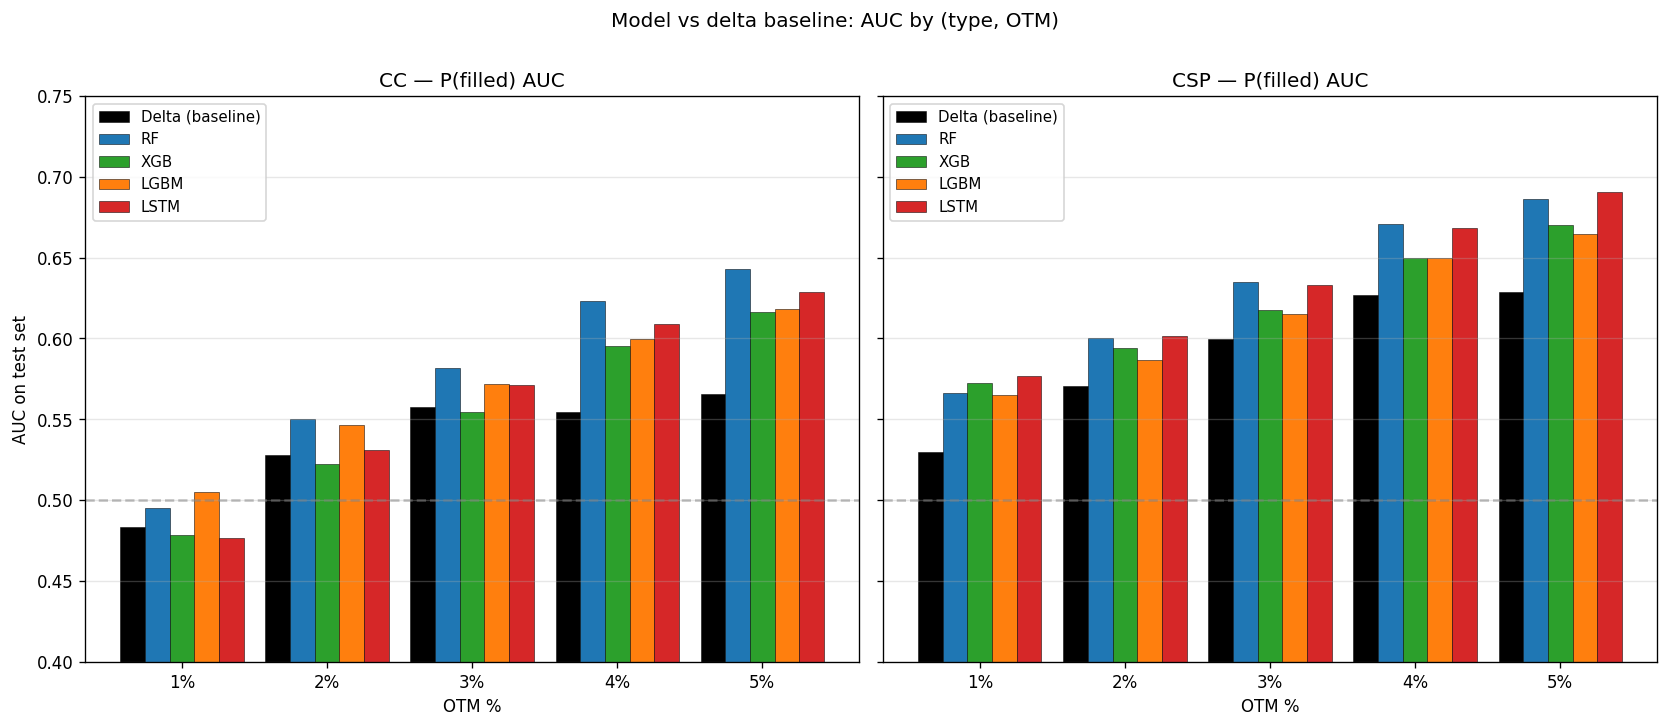

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colors = {
    "auc_delta": "black",
    "auc_rf": "tab:blue",
    "auc_xgb": "tab:green",
    "auc_lgbm": "tab:orange",
    "auc_lstm": "tab:red",
}
labels_legend = {
    "auc_delta": "Delta (baseline)",
    "auc_rf": "RF",
    "auc_xgb": "XGB",
    "auc_lgbm": "LGBM",
    "auc_lstm": "LSTM",
}
for ax, type_key in zip(axes, ["CC", "CSP"]):
    sub = eval_df[eval_df["type"] == type_key]
    x = np.arange(len(sub))
    width = 0.17
    for i, col in enumerate(["auc_delta", "auc_rf", "auc_xgb", "auc_lgbm", "auc_lstm"]):
        vals = sub[col].values.astype(float)
        offset = (i - 2) * width
        ax.bar(
            x + offset,
            vals,
            width,
            color=colors[col],
            label=labels_legend[col],
            edgecolor="black",
            linewidth=0.3,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(sub["OTM"])
    ax.set_xlabel("OTM %")
    ax.set_title(f"{type_key} — P(filled) AUC")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylim(0.4, 0.75)
    ax.grid(alpha=0.3, axis="y")
    if ax is axes[0]:
        ax.set_ylabel("AUC on test set")
    ax.legend(fontsize=9, loc="upper left")
fig.suptitle("Model vs delta baseline: AUC by (type, OTM)", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "auc_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Calibration curves

Ranking quality (AUC) isn't enough — the decision layer needs **calibrated probabilities** so that "P(filled) = 0.3" actually means 30% of such calls end up filled. If the model is well-calibrated, the calibration curve lies on the y=x diagonal.

Brier score = mean squared error of predicted probability vs actual outcome. Lower = better calibrated.

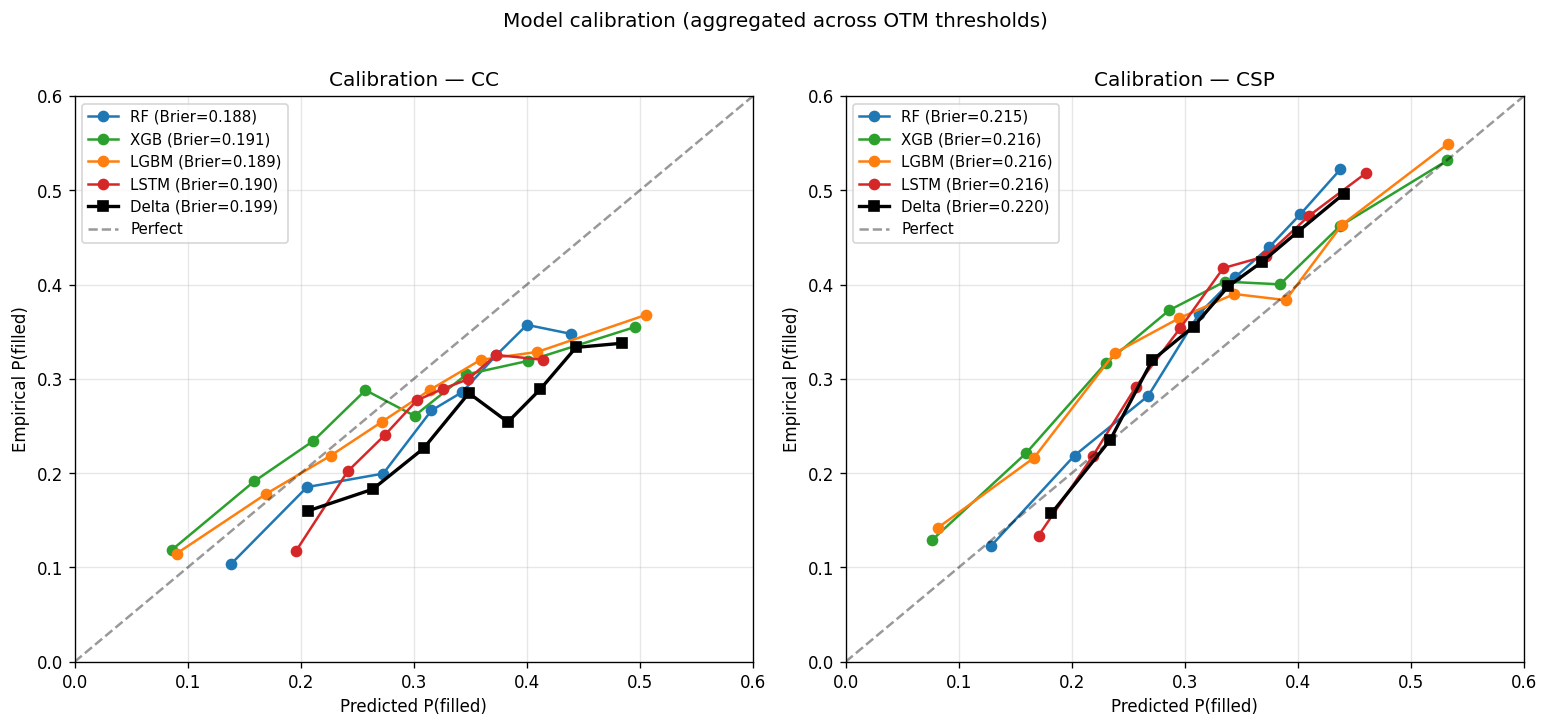

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, type_key in zip(axes, ["CC", "CSP"]):
    mask_type = test["type_cc"] == (1 if type_key == "CC" else 0)
    sub = test[mask_type]
    y = sub["filled"].values
    for col, lbl, color in [
        ("rf_proba", "RF", "tab:blue"),
        ("xgb_proba", "XGB", "tab:green"),
        ("lgbm_proba", "LGBM", "tab:orange"),
        ("lstm_proba", "LSTM", "tab:red"),
    ]:
        proba = sub[col].values
        keep = ~pd.isna(proba)
        if keep.sum() < 50:
            continue
        prob_true, prob_pred = calibration_curve(
            y[keep], proba[keep], n_bins=8, strategy="quantile"
        )
        brier = brier_score_loss(y[keep], proba[keep])
        ax.plot(
            prob_pred,
            prob_true,
            marker="o",
            color=color,
            label=f"{lbl} (Brier={brier:.3f})",
        )
    delta_keep = ~sub["p_mkt_filled"].isna()
    if delta_keep.sum() >= 50:
        pt, pp = calibration_curve(
            y[delta_keep],
            sub["p_mkt_filled"].values[delta_keep],
            n_bins=8,
            strategy="quantile",
        )
        brier_d = brier_score_loss(
            y[delta_keep], sub["p_mkt_filled"].values[delta_keep]
        )
        ax.plot(
            pp,
            pt,
            marker="s",
            color="black",
            label=f"Delta (Brier={brier_d:.3f})",
            linewidth=2,
        )
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
    ax.set_xlabel("Predicted P(filled)")
    ax.set_ylabel("Empirical P(filled)")
    ax.set_title(f"Calibration — {type_key}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 0.6)
fig.suptitle("Model calibration (aggregated across OTM thresholds)", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "calibration.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Feature importance (LightGBM, unified classifier)

Which of the 25 inputs (23 price features + `otm_pct` + `type_cc`) the unified model leans on most. `otm_pct` and `type_cc` should rank near the top since they directly shift the decision boundary; price features show the model's actual learned signal.

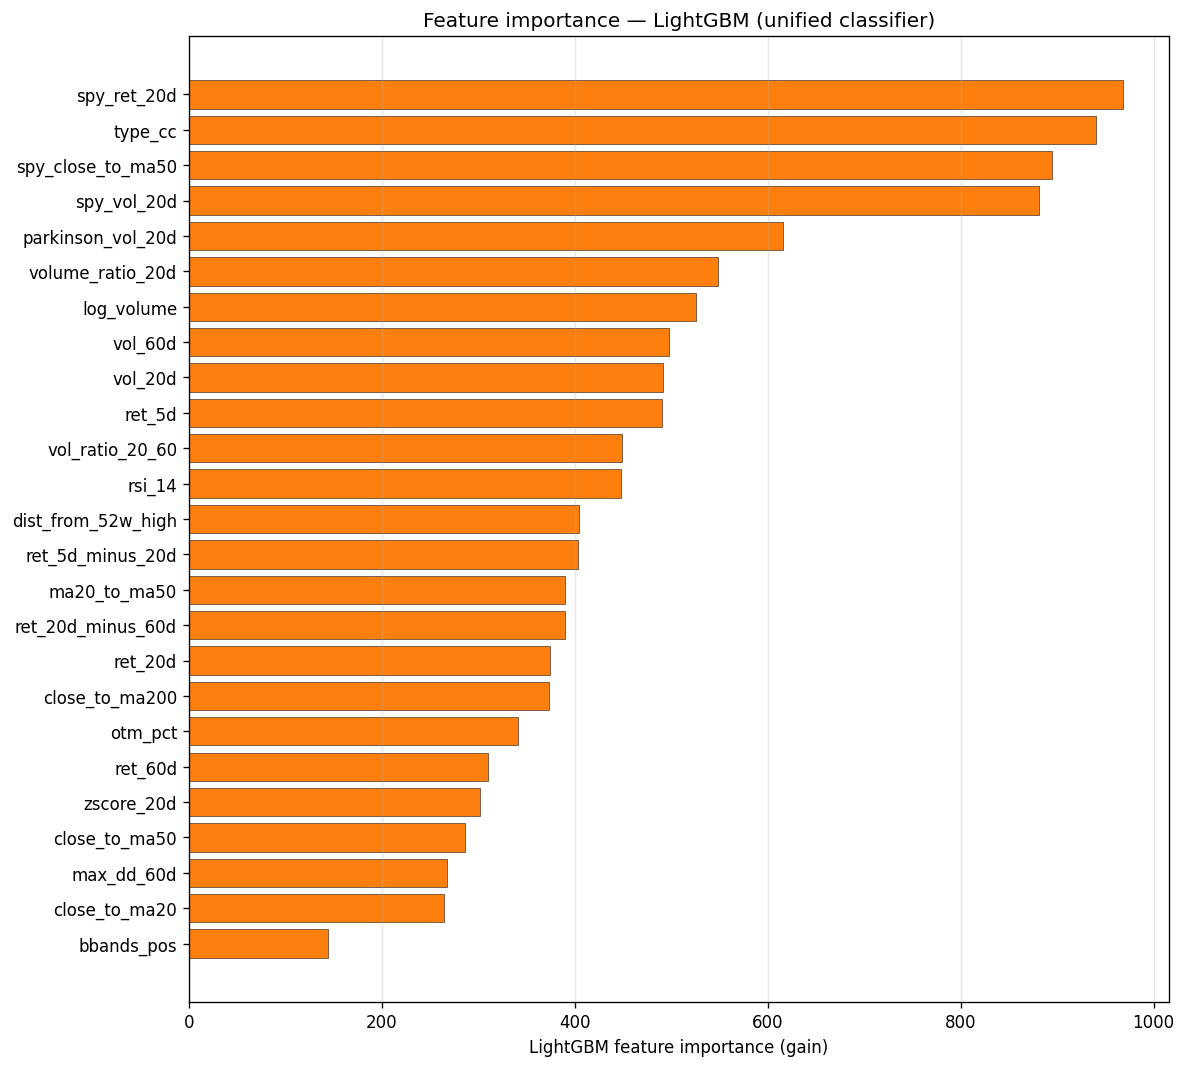

In [10]:
imp = pd.Series(lgbm_clf.feature_importances_, index=STATIC_INPUTS).sort_values()
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(imp.index, imp.values, color="tab:orange", edgecolor="black", linewidth=0.3)
ax.set_xlabel("LightGBM feature importance (gain)")
ax.set_title("Feature importance — LightGBM (unified classifier)")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(OUT_DIR / "feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Save best model + predictions

Best model by mean AUC across (type, OTM) slices: **RandomForest** (mean AUC = 0.6052).
Delta baseline mean AUC = 0.5644.

Saving the model artifact to `price_model.pkl` and the per-row predictions to `price_model_predictions.parquet` for downstream use in 07 (evaluation) and 08 (strategy backtesting with model in the loop).

In [11]:
best_col = "auc_rf"
best_name = "RandomForest"

if best_col == "auc_lgbm":
    joblib.dump(
        {"model": lgbm_clf, "feature_names": STATIC_INPUTS, "name": "LightGBM"},
        MODEL_OUT,
    )
elif best_col == "auc_xgb":
    joblib.dump(
        {"model": xgb_clf, "feature_names": STATIC_INPUTS, "name": "XGBoost"}, MODEL_OUT
    )
elif best_col == "auc_rf":
    joblib.dump(
        {"model": rf, "feature_names": STATIC_INPUTS, "name": "RandomForest"}, MODEL_OUT
    )
else:
    torch.save(
        {"state_dict": best_state, "arch": "PriceLSTM", "seq_len": SEQ_LEN}, MODEL_OUT
    )
print(f"saved {best_name} model to {MODEL_OUT}")

pred_df = test[
    [
        "ticker",
        "monday_date",
        "otm_pct",
        "type_cc",
        "type",
        "filled",
        "rf_proba",
        "xgb_proba",
        "lgbm_proba",
        "lstm_proba",
        "p_mkt_filled",
    ]
]
pred_df.to_parquet(PRED_OUT, index=False)
print(f"saved predictions to {PRED_OUT}")

saved RandomForest model to D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\data\price_model.pkl
saved predictions to D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\data\price_model_predictions.parquet
